In [1]:
import os
import shutil
import pandas as pd

# Load dataset
csv_path = "dataset_final.csv"
image_dir = "images"
base_output_dir = "cyclegan_data"

# Load the dataframe
df = pd.read_csv(csv_path)

# Define transformation map: from_stage → to_stage
transition_map = {
    1: 2,
    2: 3,
    3: 4,
    4: 5,
    5: 6,
    6: 7,
    7: 7
}

# Create the folder structure and copy files
for from_stage, to_stage in transition_map.items():
    # Filter images for current 'from_stage'
    from_stage_df = df[df["label"] == from_stage]

    # Define paths
    pair_name = f"stage{from_stage}_to_{to_stage}"
    trainA_dir = os.path.join(base_output_dir, pair_name, "trainA")  # source domain
    trainB_dir = os.path.join(base_output_dir, pair_name, "trainB")  # target domain

    os.makedirs(trainA_dir, exist_ok=True)
    os.makedirs(trainB_dir, exist_ok=True)

    # Get images for from_stage and to_stage
    to_stage_df = df[df["label"] == to_stage]

    # Balance: same number of A and B samples
    n = min(len(from_stage_df), len(to_stage_df))

    from_stage_df = from_stage_df.sample(n, random_state=42)
    to_stage_df = to_stage_df.sample(n, random_state=42)

    # Copy images into trainA (from_stage)
    for _, row in from_stage_df.iterrows():
        src = os.path.join(image_dir, row["image"])
        dst = os.path.join(trainA_dir, row["image"])
        if os.path.exists(src):
            shutil.copy(src, dst)
        else:
            print(f"⚠️ Missing A: {src}")

    # Copy images into trainB (to_stage)
    for _, row in to_stage_df.iterrows():
        src = os.path.join(image_dir, row["image"])
        dst = os.path.join(trainB_dir, row["image"])
        if os.path.exists(src):
            shutil.copy(src, dst)
        else:
            print(f"⚠️ Missing B: {src}")

print("\n✅ Folder structure created for CycleGAN training.")



✅ Folder structure created for CycleGAN training.


In [2]:
%pip install torch torchvision torchaudio


  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ------------------------

In [3]:
# 1. Setup & Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.utils import save_image

# 2. Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Folder setup (already created by you):
# dataset/cyclegan/stage1to2/trainA  -> Stage 1 images
# dataset/cyclegan/stage1to2/trainB  -> Stage 2 images
# Repeat for stage2to3, stage3to4 etc.

# 4. Define the generator and discriminator
# Basic ResNet Generator and PatchGAN Discriminator from CycleGAN paper
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, 64, kernel_size=7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        # Downsample
        in_channels = 64
        out_channels = in_channels * 2
        for _ in range(2):
            model += [
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
                nn.InstanceNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ]
            in_channels = out_channels
            out_channels *= 2

        # Residual blocks
        for _ in range(6):
            model += [ResidualBlock(in_channels)]

        # Upsample
        out_channels = in_channels // 2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=3, stride=2,
                                   padding=1, output_padding=1),
                nn.InstanceNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ]
            in_channels = out_channels
            out_channels = in_channels // 2

        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, 3, kernel_size=7),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def disc_block(in_channels, out_channels, stride):
            return [
                nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=stride, padding=1),
                nn.InstanceNorm2d(out_channels),
                nn.LeakyReLU(0.2, inplace=True)
            ]

        model = [
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        ]
        model += disc_block(64, 128, 2)
        model += disc_block(128, 256, 2)
        model += disc_block(256, 512, 1)
        model += [nn.Conv2d(512, 1, kernel_size=4, padding=1)]  # PatchGAN output

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

# ✅ You're now ready with the model architecture.
# Next steps:
# - Load dataset (Stage1 → Stage2 etc.)
# - Train CycleGAN with identity, adversarial, cycle loss
# - Save generated images in /results

# Want me to continue with dataset loading and training loop?


In [8]:
import os
import shutil

def fix_imagefolder_structure(path):
    class_path = os.path.join(path, "class_dummy")
    os.makedirs(class_path, exist_ok=True)
    
    for fname in os.listdir(path):
        src = os.path.join(path, fname)
        dst = os.path.join(class_path, fname)
        if os.path.isfile(src):
            shutil.move(src, dst)

fix_imagefolder_structure("cyclegan_data/stage1_to_2/trainA")
fix_imagefolder_structure("cyclegan_data/stage1_to_2/trainB")


In [9]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Image transform: resize, convert to tensor, normalize
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load datasets
dataset_A = datasets.ImageFolder(root='cyclegan_data/stage1_to_2/trainA', transform=transform)
dataset_B = datasets.ImageFolder(root='cyclegan_data/stage1_to_2/trainB', transform=transform)

# Just need the image paths inside, so we ignore class subfolders
loader_A = DataLoader(dataset_A, batch_size=1, shuffle=True)
loader_B = DataLoader(dataset_B, batch_size=1, shuffle=True)

# Zip loaders to get unaligned training pairs
def unaligned_data_loader(loader_A, loader_B):
    while True:
        for a, b in zip(loader_A, loader_B):
            yield a[0], b[0]

# Get a batch pair example
data_iter = unaligned_data_loader(loader_A, loader_B)
real_A, real_B = next(data_iter)

print(f"Sample image shapes: A={real_A.shape}, B={real_B.shape}")


Sample image shapes: A=torch.Size([1, 3, 256, 256]), B=torch.Size([1, 3, 256, 256])


In [10]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(features, features, kernel_size=3, padding=1),
            nn.InstanceNorm2d(features),
            nn.ReLU(inplace=True),
            nn.Conv2d(features, features, kernel_size=3, padding=1),
            nn.InstanceNorm2d(features)
        )

    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, n_residuals=9):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, 64, kernel_size=7, padding=3),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]
        
        # Downsampling
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            layers += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features
            out_features = in_features * 2
        
        # Residual blocks
        for _ in range(n_residuals):
            layers.append(ResidualBlock(in_features))
        
        # Upsampling
        out_features = in_features // 2
        for _ in range(2):
            layers += [
                nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features
            out_features = in_features // 2
        
        # Output layer
        layers += [
            nn.Conv2d(64, out_channels, kernel_size=7, padding=3),
            nn.Tanh()
        ]
        
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


In [11]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        def block(in_c, out_c, normalize=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        
        self.model = nn.Sequential(
            *block(in_channels, 64, normalize=False),
            *block(64, 128),
            *block(128, 256),
            *block(256, 512),
            nn.Conv2d(512, 1, 4, padding=1)  # Output: Patch prediction map
        )

    def forward(self, x):
        return self.model(x)


In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G_AB = Generator().to(device)  # A → B (e.g., Stage 1 → Stage 2)
G_BA = Generator().to(device)  # B → A

D_A = Discriminator().to(device)
D_B = Discriminator().to(device)


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

# Loss functions
criterion_GAN = nn.MSELoss()          # Adversarial loss
criterion_cycle = nn.L1Loss()         # Cycle consistency loss
criterion_identity = nn.L1Loss()      # Identity loss


In [14]:
# Optimizers for Generators and Discriminators
lr = 0.0002
beta1 = 0.5
beta2 = 0.999

optimizer_G = optim.Adam(
    list(G_AB.parameters()) + list(G_BA.parameters()),
    lr=lr, betas=(beta1, beta2)
)
optimizer_D_A = optim.Adam(D_A.parameters(), lr=lr, betas=(beta1, beta2))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=lr, betas=(beta1, beta2))


In [15]:
import random

class ImagePool():
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.images = []

    def push_and_pop(self, images):
        selected = []
        for img in images:
            img = torch.unsqueeze(img.data, 0)
            if len(self.images) < self.max_size:
                self.images.append(img)
                selected.append(img)
            else:
                if random.random() > 0.5:
                    idx = random.randint(0, self.max_size - 1)
                    tmp = self.images[idx].clone()
                    self.images[idx] = img
                    selected.append(tmp)
                else:
                    selected.append(img)
        return torch.cat(selected)


In [16]:
fake_A_pool = ImagePool()
fake_B_pool = ImagePool()


In [18]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data transforms (resize to 256x256 and normalize to [-1, 1])
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # from [0,1] to [-1,1]
])

# Load datasets
dataset_A = datasets.ImageFolder(root='cyclegan_data/stage1_to_2/trainA', transform=transform)
dataset_B = datasets.ImageFolder(root='cyclegan_data/stage1_to_2/trainB', transform=transform)

# DataLoaders
dataloader_A = DataLoader(dataset_A, batch_size=1, shuffle=True)
dataloader_B = DataLoader(dataset_B, batch_size=1, shuffle=True)


In [20]:
import itertools
from tqdm import tqdm

num_epochs = 10
lambda_cycle = 10.0
lambda_identity = 5.0  # Optional

for epoch in range(1, num_epochs + 1):
    print(f"\n🧠 Epoch {epoch}/{num_epochs}")
    for i, (data_A, data_B) in enumerate(zip(dataloader_A, dataloader_B)):

        real_A = data_A[0].to(device)
        real_B = data_B[0].to(device)

        # 1️⃣ Train Generators
        optimizer_G.zero_grad()

        # Identity loss
        same_B = G_AB(real_B)
        loss_identity_B = criterion_identity(same_B, real_B) * lambda_identity

        same_A = G_BA(real_A)
        loss_identity_A = criterion_identity(same_A, real_A) * lambda_identity

        # GAN loss
        fake_B = G_AB(real_A)
        pred_fake_B = D_B(fake_B)
        loss_GAN_AB = criterion_GAN(pred_fake_B, torch.ones_like(pred_fake_B))

        fake_A = G_BA(real_B)
        pred_fake_A = D_A(fake_A)
        loss_GAN_BA = criterion_GAN(pred_fake_A, torch.ones_like(pred_fake_A))

        # Cycle loss
        recovered_A = G_BA(fake_B)
        loss_cycle_A = criterion_cycle(recovered_A, real_A) * lambda_cycle

        recovered_B = G_AB(fake_A)
        loss_cycle_B = criterion_cycle(recovered_B, real_B) * lambda_cycle

        # Total Generator loss
        loss_G = (loss_identity_A + loss_identity_B +
                  loss_GAN_AB + loss_GAN_BA +
                  loss_cycle_A + loss_cycle_B)

        loss_G.backward()
        optimizer_G.step()

        # 2️⃣ Train Discriminator A
        optimizer_D_A.zero_grad()

        # Real loss
        pred_real_A = D_A(real_A)
        loss_D_real_A = criterion_GAN(pred_real_A, torch.ones_like(pred_real_A))

        # Fake loss
        fake_A_detach = fake_A_pool.push_and_pop(fake_A)
        pred_fake_A = D_A(fake_A_detach.detach())
        loss_D_fake_A = criterion_GAN(pred_fake_A, torch.zeros_like(pred_fake_A))

        loss_D_A = (loss_D_real_A + loss_D_fake_A) * 0.5
        loss_D_A.backward()
        optimizer_D_A.step()

        # 3️⃣ Train Discriminator B
        optimizer_D_B.zero_grad()

        pred_real_B = D_B(real_B)
        loss_D_real_B = criterion_GAN(pred_real_B, torch.ones_like(pred_real_B))

        fake_B_detach = fake_B_pool.push_and_pop(fake_B)
        pred_fake_B = D_B(fake_B_detach.detach())
        loss_D_fake_B = criterion_GAN(pred_fake_B, torch.zeros_like(pred_fake_B))

        loss_D_B = (loss_D_real_B + loss_D_fake_B) * 0.5
        loss_D_B.backward()
        optimizer_D_B.step()

        if i % 10 == 0:
            print(f"[{i}] Loss_G: {loss_G.item():.4f} | D_A: {loss_D_A.item():.4f} | D_B: {loss_D_B.item():.4f}")



🧠 Epoch 1/10
[0] Loss_G: 7.0859 | D_A: 0.1491 | D_B: 0.1864
[10] Loss_G: 12.8328 | D_A: 0.1877 | D_B: 0.2083

🧠 Epoch 2/10
[0] Loss_G: 7.1441 | D_A: 0.2712 | D_B: 0.2020
[10] Loss_G: 6.4273 | D_A: 0.1490 | D_B: 0.1862

🧠 Epoch 3/10
[0] Loss_G: 9.6319 | D_A: 0.1846 | D_B: 0.1606
[10] Loss_G: 9.3188 | D_A: 0.1172 | D_B: 0.2497

🧠 Epoch 4/10
[0] Loss_G: 5.9395 | D_A: 0.1268 | D_B: 0.1579
[10] Loss_G: 4.0863 | D_A: 0.3097 | D_B: 0.3676

🧠 Epoch 5/10
[0] Loss_G: 8.8245 | D_A: 0.1237 | D_B: 0.0420
[10] Loss_G: 8.2726 | D_A: 0.0961 | D_B: 0.0813

🧠 Epoch 6/10
[0] Loss_G: 7.6942 | D_A: 0.1259 | D_B: 0.1321
[10] Loss_G: 5.9642 | D_A: 0.2886 | D_B: 0.3478

🧠 Epoch 7/10
[0] Loss_G: 6.8892 | D_A: 0.1437 | D_B: 0.1513
[10] Loss_G: 5.8024 | D_A: 0.4090 | D_B: 0.2418

🧠 Epoch 8/10
[0] Loss_G: 12.7936 | D_A: 0.0544 | D_B: 0.1526
[10] Loss_G: 7.5163 | D_A: 0.1697 | D_B: 0.2060

🧠 Epoch 9/10
[0] Loss_G: 6.2171 | D_A: 0.2126 | D_B: 0.0431
[10] Loss_G: 5.5180 | D_A: 0.0927 | D_B: 0.1471

🧠 Epoch 10/10
[0

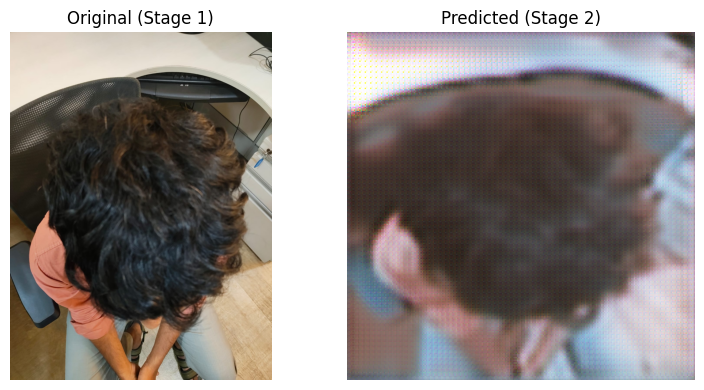

In [22]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load the generator that converts Stage 1 to Stage 2
G_AB.eval()  # Set to evaluation mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G_AB = G_AB.to(device)

# Define transform (same as training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Reverse transform (to display)
def denormalize(tensor):
    tensor = tensor * 0.5 + 0.5  # [-1,1] → [0,1]
    tensor = tensor.clamp(0, 1)
    return tensor

# Load and preprocess your Stage 1 test image
img_path = "test_data1.jpeg"  # Replace this path
img = Image.open(img_path).convert("RGB")
input_tensor = transform(img).unsqueeze(0).to(device)

# Run through the generator
with torch.no_grad():
    fake_B = G_AB(input_tensor)

# Convert to image for viewing
generated_img = denormalize(fake_B.squeeze()).permute(1, 2, 0).cpu().numpy()

# Plot original and generated
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original (Stage 1)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(generated_img)
plt.title("Predicted (Stage 2)")
plt.axis("off")
plt.tight_layout()
plt.show()
